<a href="https://colab.research.google.com/github/TingyuZhao19/MSSP6070/blob/main/Assignments/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BASE = '/content/drive/MyDrive/MSSP607/Assignments/data_academic_performance.csv'

# Task
Analyze the provided academic performance dataset to determine the following tasks:
1. Does parental education influence outcomes, and if so, how much?
2. Which groups/stratum performs best? Are there differences between groups/stratums? Explain your analysis.
3. How does each gender perform in the global assessment?
4. Use your analysis to understand the results.  What did you find interesting, and can you make any recommendations or inferences?.

Use the dataset "academic_performance.csv".

# Load data



In [3]:
df = pd.read_csv(BASE)
display(df.head())

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


## Explore Data

### Subtask:
Display the first few rows and the columns of the DataFrame to understand its structure and identify relevant columns.

In [4]:
display(df.head())
display(df.columns)

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


Index(['COD_S11', 'GENDER', 'EDU_FATHER', 'EDU_MOTHER', 'OCC_FATHER',
       'OCC_MOTHER', 'STRATUM', 'SISBEN', 'PEOPLE_HOUSE', 'Unnamed: 9',
       'INTERNET', 'TV', 'COMPUTER', 'WASHING_MCH', 'MIC_OVEN', 'CAR', 'DVD',
       'FRESH', 'PHONE', 'MOBILE', 'REVENUE', 'JOB', 'SCHOOL_NAME',
       'SCHOOL_NAT', 'SCHOOL_TYPE', 'MAT_S11', 'CR_S11', 'CC_S11', 'BIO_S11',
       'ENG_S11', 'Cod_SPro', 'UNIVERSITY', 'ACADEMIC_PROGRAM', 'QR_PRO',
       'CR_PRO', 'CC_PRO', 'ENG_PRO', 'WC_PRO', 'FEP_PRO', 'G_SC',
       'PERCENTILE', '2ND_DECILE', 'QUARTILE', 'SEL', 'SEL_IHE'],
      dtype='object')

# **Quantify Influence**

## Influence on GLobal Score

### Subtask:
Investigate the relationship between parental education levels and academic outcomes by grouping data by parental education and examining average global scores.

In [5]:
# Analyze the relationship between father's education and global score
father_education_impact = df.groupby('EDU_FATHER')['G_SC'].mean().sort_values()
display(father_education_impact)

# Analyze the relationship between mother's education and global score
mother_education_impact = df.groupby('EDU_MOTHER')['G_SC'].mean().sort_values()
display(mother_education_impact)

,G_SC
EDU_FATHER,
0,155.076726
Complete primary,155.195388
Incomplete primary,155.729252
Incomplete Secundary,156.535289
Ninguno,156.634146
Complete Secundary,158.785790
Not sure,160.294840
Incomplete technical or technological,162.101083
Complete technique or technology,164.033501


,G_SC
EDU_MOTHER,
Ninguno,149.705882
Incomplete primary,154.853974
0,154.930412
Complete primary,155.336606
Incomplete Secundary,155.672348
Complete Secundary,158.470702
Not sure,159.407821
Incomplete technical or technological,161.879765
Complete technique or technology,163.242140


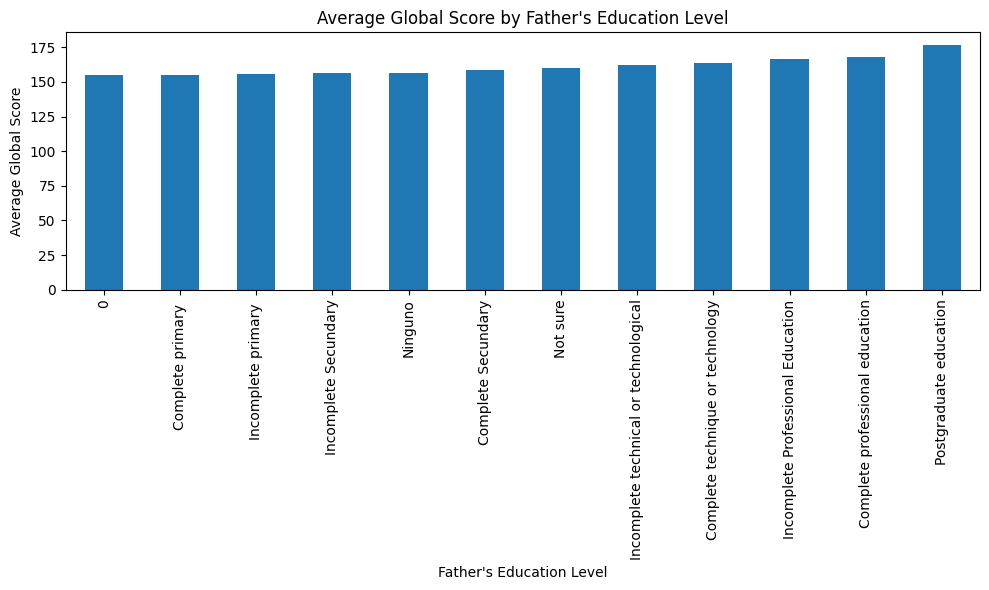

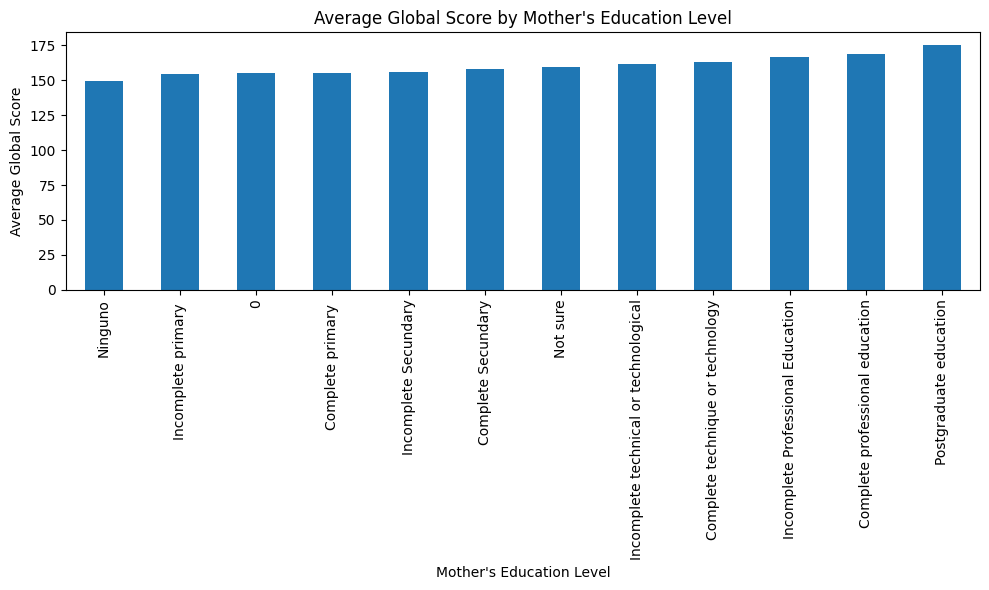

In [6]:
# Visualize the influence of father's education on global score
plt.figure(figsize=(10, 6))
father_education_impact.plot(kind='bar')
plt.title("Average Global Score by Father's Education Level")
plt.xlabel("Father's Education Level")
plt.ylabel("Average Global Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Visualize the influence of mother's education on global score
plt.figure(figsize=(10, 6))
mother_education_impact.plot(kind='bar')
plt.title("Average Global Score by Mother's Education Level")
plt.xlabel("Mother's Education Level")
plt.ylabel("Average Global Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**General Trend**: There is a general trend showing that as the level of parental education increases, the average global score of students also tends to increase.

**Comparison between Father's and Mother's Education**: Both father's and mother's education levels show a similar pattern of influence on student outcomes. Higher education levels in either parent are associated with higher average global scores in students.

## **Measure Influence of Parental Education on S11 Scores**

### Subtask:
Investigate the relationship between parental education levels and each of the S11 subject scores by grouping data by parental education and examining average scores, and visualize the results.

In [7]:
from sklearn.decomposition import PCA
import statsmodels.formula.api as smf

S11_cols = ["MAT_S11","CR_S11","CC_S11","BIO_S11","ENG_S11"]
# Keep numeric
for c in S11_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 1) Standardize each subject (z-scores)
Z = df[S11_cols].apply(lambda x: (x - x.mean())/x.std(ddof=1))

# 2) Mean-of-z composite (require at least 3 subjects present)
df["S11_index"] = Z.mean(axis=1, skipna=True)
valid_counts = Z.notna().sum(axis=1)
df.loc[valid_counts < 3, "S11_index"] = np.nan

# 3) Cronbach’s alpha
k = Z.shape[1]
item_vars = Z.var(ddof=1, axis=0)
total_var = Z.sum(axis=1).var(ddof=1)
alpha = (k / (k-1)) * (1 - item_vars.sum() / total_var)
print("Cronbach alpha (S11):", round(alpha, 3))

Cronbach alpha (S11): 0.896


In [8]:
# Analyze the relationship between father's education and S11 scores by displaying the mean scores
father_education_s11_impact = df.groupby('EDU_FATHER')[S11_cols].mean()
print("Average S11 Scores by Father's Education Level:")
display(father_education_s11_impact)

# Analyze the relationship between mother's education and S11 scores by displaying the mean scores
mother_education_s11_impact = df.groupby('EDU_MOTHER')[S11_cols].mean()
print("\nAverage S11 Scores by Mother's Education Level:")
display(mother_education_s11_impact)

Average S11 Scores by Father's Education Level:


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11
EDU_FATHER,,,,,
0,59.179028,56.946292,57.199488,60.153453,55.383632
Complete Secundary,62.282800,59.427014,59.297573,62.071403,58.040802
Complete primary,60.660194,57.983010,58.552184,60.791262,54.888350
Complete professional education,67.013594,62.490053,62.370690,66.208886,66.833886
Complete technique or technology,64.881072,61.294807,61.268007,64.365159,62.198492
Incomplete Professional Education,66.268235,62.378824,62.157647,65.689412,65.190588
Incomplete Secundary,61.271311,58.709441,58.662695,61.274060,56.535289
Incomplete primary,61.250340,58.523810,58.782313,61.331973,55.945578
Incomplete technical or technological,63.389892,60.606498,59.985560,63.718412,60.263538



Average S11 Scores by Mother's Education Level:


,MAT_S11,CR_S11,CC_S11,BIO_S11,ENG_S11
EDU_MOTHER,,,,,
0,59.126289,57.074742,57.059278,59.979381,55.605670
Complete Secundary,62.186735,59.241468,59.324855,62.005795,57.697682
Complete primary,60.504909,57.767181,58.395512,61.151473,55.029453
Complete professional education,67.440994,62.783916,62.579928,66.614253,67.685518
Complete technique or technology,64.557191,61.272910,61.197324,64.035452,62.270903
Incomplete Professional Education,65.990040,62.796813,62.256972,65.155378,64.296813
Incomplete Secundary,60.949811,58.340909,58.518939,61.020833,56.048295
Incomplete primary,60.824399,58.225508,58.258780,61.243993,54.951941
Incomplete technical or technological,64.038123,61.492669,60.756598,63.870968,61.134897


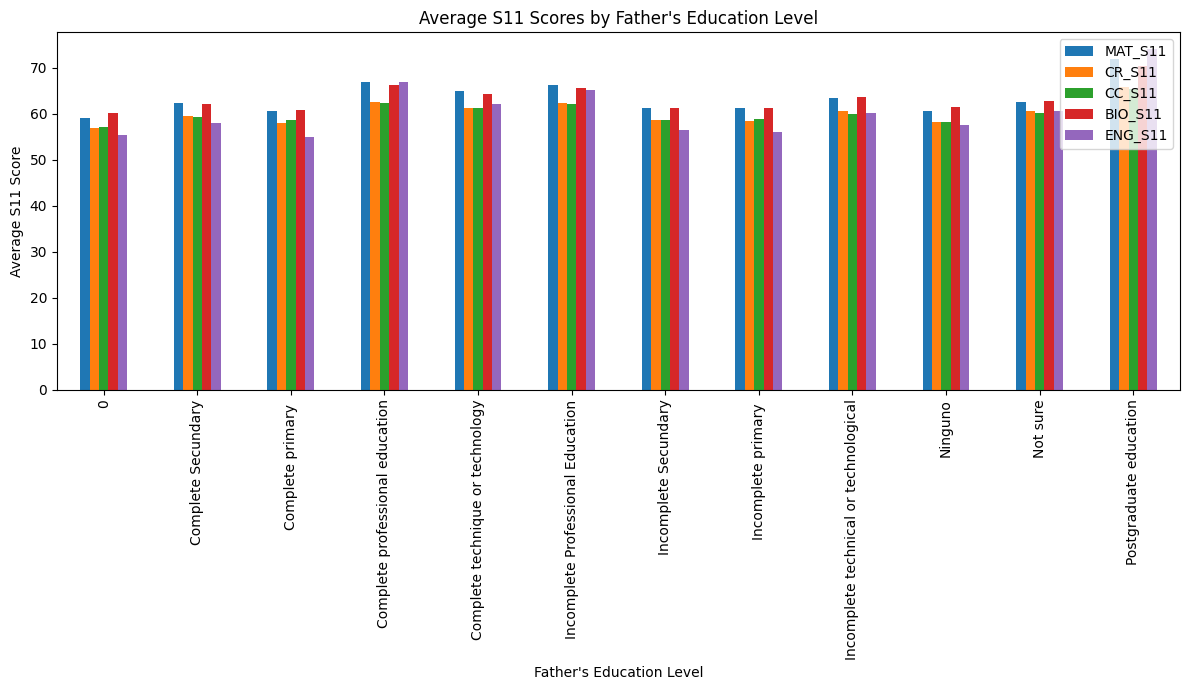

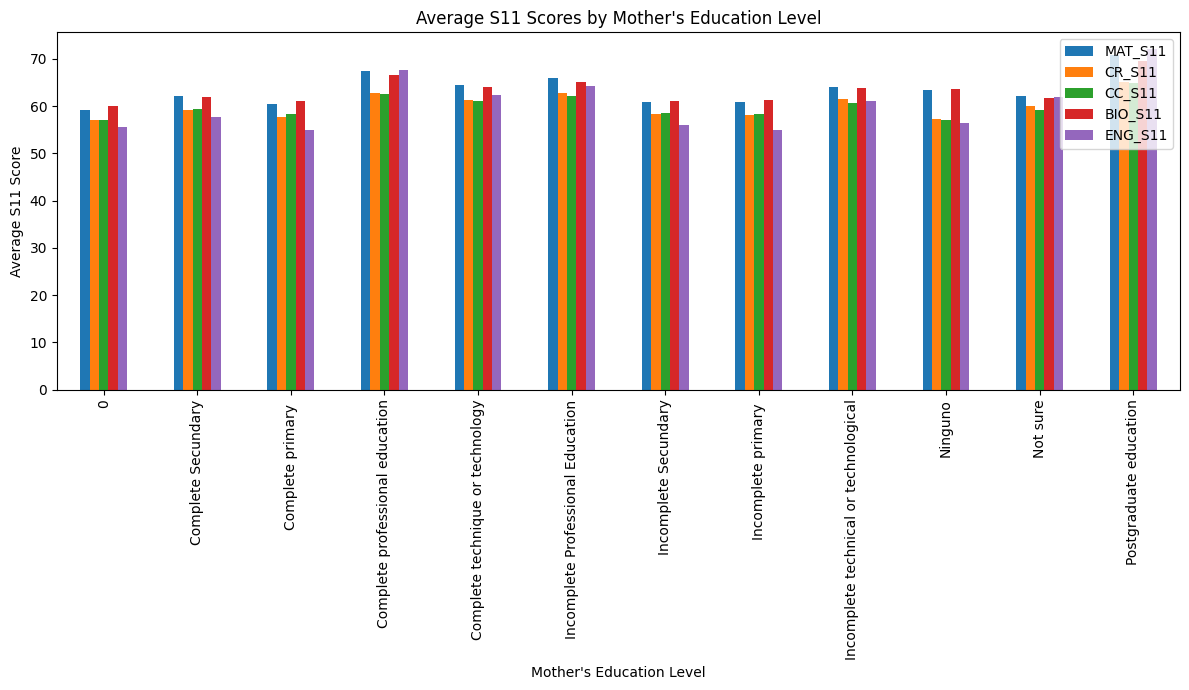

In [9]:
# Visualize the influence of father's education on S11 scores
father_education_s11_impact.plot(kind='bar', figsize=(12, 7))
plt.title("Average S11 Scores by Father's Education Level")
plt.xlabel("Father's Education Level")
plt.ylabel("Average S11 Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Visualize the influence of mother's education on S11 scores
mother_education_s11_impact.plot(kind='bar', figsize=(12, 7))
plt.title("Average S11 Scores by Mother's Education Level")
plt.xlabel("Mother's Education Level")
plt.ylabel("Average S11 Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
# Map raw labels → ordered integers (edit labels to match the dataset exactly)
order = [
    "Ninguno", "0", "Not sure",
    "Incomplete primary", "Complete primary",
    "Incomplete Secundary", "Complete Secundary",
    "Incomplete technical or technological", "Complete technique or technology",
    "Incomplete Professional Education", "Complete professional education",
    "Postgraduate education",
]
order_map = {k:i for i,k in enumerate(order)}

def norm(x):  # normalize spacing/case a bit
    return str(x).strip().replace("  ", " ")

for col in ["EDU_FATHER","EDU_MOTHER","GENDER","SISBEN"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().map(norm)

df["EDU_F_LVL"] = df["EDU_FATHER"].map(order_map)
df["EDU_M_LVL"] = df["EDU_MOTHER"].map(order_map)

# Use the higher of the two (common in edu research)
df["PARENT_ED_MAX"] = df[["EDU_F_LVL","EDU_M_LVL"]].max(axis=1)


In [11]:
# Mean S11_index by parental education (ordered)
pe_means = (df.dropna(subset=["PARENT_ED_MAX","S11_index"])
              .groupby("PARENT_ED_MAX")["S11_index"].agg(n="size", mean="mean", sd="std"))
display(pe_means)

# Top–bottom standardized gap (SD units)
if pe_means.shape[0] >= 2:
    gap_sd = pe_means.iloc[-1]["mean"] - pe_means.iloc[0]["mean"]
    print("Top–bottom gap on S11_index (SD units):", round(gap_sd, 2))

# Bootstrap 95% CI for the top–bottom gap (optional but recommended)
rng = np.random.default_rng(42)
sub = df.dropna(subset=["PARENT_ED_MAX","S11_index"]).copy()
lo_lvl, hi_lvl = sub["PARENT_ED_MAX"].min(), sub["PARENT_ED_MAX"].max()
a = sub.loc[sub["PARENT_ED_MAX"]==hi_lvl, "S11_index"].to_numpy()
b = sub.loc[sub["PARENT_ED_MAX"]==lo_lvl, "S11_index"].to_numpy()
B=3000
gaps = rng.choice(a, (B, a.size), True).mean(axis=1) - rng.choice(b, (B, b.size), True).mean(axis=1)
ci = np.percentile(gaps, [2.5,97.5])
print("95% CI for gap:", [round(ci[0],2), round(ci[1],2)])

# Gender and SISBEN descriptives (nice to report)
by_gender = df.groupby("GENDER")["S11_index"].agg(n="size", mean="mean", sd="std")
by_sisben = df.groupby("SISBEN")["S11_index"].agg(n="size", mean="mean", sd="std")
display(by_gender, by_sisben)

,n,mean,sd
PARENT_ED_MAX,,,
0,18,-0.372294,0.948715
1,327,-0.410394,0.688786
2,120,-0.187051,0.881058
3,372,-0.317044,0.771814
4,526,-0.356119,0.746606
5,788,-0.311752,0.745742
6,2702,-0.230432,0.767804
7,301,-0.071271,0.753967
8,1387,-0.065319,0.792347


Top–bottom gap on S11_index (SD units): 0.9
95% CI for gap: [np.float64(0.47), np.float64(1.32)]


,n,mean,sd
GENDER,,,
F,5043,-0.087677,0.800715
M,7368,0.060010,0.862026


,n,mean,sd
SISBEN,,,
0,21,-0.423552,0.786302
Esta clasificada en otro Level del SISBEN,96,-0.010361,0.805801
It is not classified by the SISBEN,7534,0.194802,0.830099
Level 1,2057,-0.383713,0.756034
Level 2,2120,-0.287180,0.762234
Level 3,583,-0.102284,0.750388


In [12]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Keep only rows with all needed variables
needed = ["S11_index","PARENT_ED_MAX","GENDER","SISBEN"]
mod_df = df.dropna(subset=needed).copy()

# OLS with HC3 robust SEs
m_s11 = smf.ols("S11_index ~ PARENT_ED_MAX + C(GENDER) + C(SISBEN)", data=mod_df).fit(cov_type="HC3")
display(m_s11.summary().tables[1])

# Partial R² for parental education (unique variance explained)
m_red = smf.ols("S11_index ~ C(GENDER) + C(SISBEN)", data=mod_df).fit(cov_type="HC3")
rss_full = np.sum(m_s11.resid**2)
rss_red  = np.sum(m_red.resid**2)
partial_R2_PE = 1 - rss_full/rss_red if rss_red>0 else np.nan
display("Partial R² (PE | Gender, SISBEN):", round(partial_R2_PE, 3))

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-0.5754,0.186,-3.101,0.002,-0.939,-0.212
C(GENDER)[T.M],0.1455,0.014,10.300,0.000,0.118,0.173
C(SISBEN)[T.Esta clasificada en otro Level del SISBEN],-0.1000,0.204,-0.490,0.624,-0.500,0.300
C(SISBEN)[T.It is not classified by the SISBEN],0.0950,0.187,0.509,0.611,-0.271,0.461
C(SISBEN)[T.Level 1],-0.3232,0.187,-1.732,0.083,-0.689,0.043
C(SISBEN)[T.Level 2],-0.2586,0.187,-1.385,0.166,-0.625,0.107
C(SISBEN)[T.Level 3],-0.1503,0.189,-0.796,0.426,-0.521,0.220
PARENT_ED_MAX,0.0687,0.003,24.163,0.000,0.063,0.074


'Partial R² (PE | Gender, SISBEN):'

np.float64(0.044)

In [13]:
m_int_g = smf.ols("S11_index ~ PARENT_ED_MAX*C(GENDER) + C(SISBEN)", data=mod_df).fit(cov_type="HC3")
m_int_s = smf.ols("S11_index ~ PARENT_ED_MAX*C(SISBEN) + C(GENDER)", data=mod_df).fit(cov_type="HC3")
display(m_int_g.summary().tables[1])
display(m_int_s.summary().tables[1])

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-0.5423,0.184,-2.950,0.003,-0.903,-0.182
C(GENDER)[T.M],0.0879,0.043,2.062,0.039,0.004,0.172
C(SISBEN)[T.Esta clasificada en otro Level del SISBEN],-0.1007,0.201,-0.501,0.617,-0.495,0.294
C(SISBEN)[T.It is not classified by the SISBEN],0.0966,0.183,0.526,0.599,-0.263,0.456
C(SISBEN)[T.Level 1],-0.3214,0.183,-1.753,0.080,-0.681,0.038
C(SISBEN)[T.Level 2],-0.2574,0.183,-1.403,0.161,-0.617,0.102
C(SISBEN)[T.Level 3],-0.1489,0.186,-0.802,0.423,-0.513,0.215
PARENT_ED_MAX,0.0643,0.004,15.831,0.000,0.056,0.072
PARENT_ED_MAX:C(GENDER)[T.M],0.0074,0.005,1.400,0.161,-0.003,0.018


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-0.4838,0.097,-5.005,0.000,-0.673,-0.294
C(SISBEN)[T.Esta clasificada en otro Level del SISBEN],0.2621,0.251,1.045,0.296,-0.229,0.753
C(SISBEN)[T.It is not classified by the SISBEN],-0.2336,0.101,-2.315,0.021,-0.431,-0.036
C(SISBEN)[T.Level 1],-0.0767,0.104,-0.736,0.462,-0.281,0.128
C(SISBEN)[T.Level 2],-0.1431,0.105,-1.362,0.173,-0.349,0.063
C(SISBEN)[T.Level 3],0.0384,0.135,0.284,0.776,-0.226,0.303
C(GENDER)[T.M],0.1452,0.014,10.331,0.000,0.118,0.173
PARENT_ED_MAX,-0.0227,0.096,-0.236,0.814,-0.212,0.166
PARENT_ED_MAX:C(SISBEN)[T.Esta clasificada en otro Level del SISBEN],0.0358,0.094,0.381,0.703,-0.148,0.220
PARENT_ED_MAX:C(SISBEN)[T.It is not classified by the SISBEN],0.1191,0.096,1.236,0.216,-0.070,0.308


In [14]:
print("Cronbach alpha (S11):", round(alpha, 3))
print("\nMean S11 index by parental education (ordered):")
display(pe_means)
print("\nTop–bottom gap on S11_index (SD units):", round(gap_sd, 2))
print("95% CI for gap:", [round(ci[0],2), round(ci[1],2)])
print("\nPartial R² (PE | Gender, SISBEN):", round(partial_R2_PE, 3))

Cronbach alpha (S11): 0.896

Mean S11 index by parental education (ordered):


,n,mean,sd
PARENT_ED_MAX,,,
0,18,-0.372294,0.948715
1,327,-0.410394,0.688786
2,120,-0.187051,0.881058
3,372,-0.317044,0.771814
4,526,-0.356119,0.746606
5,788,-0.311752,0.745742
6,2702,-0.230432,0.767804
7,301,-0.071271,0.753967
8,1387,-0.065319,0.792347



Top–bottom gap on S11_index (SD units): 0.9
95% CI for gap: [np.float64(0.47), np.float64(1.32)]

Partial R² (PE | Gender, SISBEN): 0.044


# Interpretation:
1. The analysis shows a clear relationship between parental education levels and student performance on the S11 assessment.

2. Students whose parents have higher levels of education tend to achieve higher S11 scores. This is evident from the mean S11 index by parental education level, which shows a general increase in the average S11 index as parental education increases.

3. The "top-bottom gap" of 0.90 SD units indicates a substantial difference in performance between students with the highest and lowest levels of parental education, equivalent to almost a full standard deviation in S11 scores.

4. Furthermore, the partial R² of 0.044 suggests that parental education uniquely explains about 4.4% of the variance in S11 scores, even after accounting for gender and SISBEN classification. This indicates that parental education has a notable influence on student performance, independent of these other factors.

## Influence on PRO Scores

### Subtask:
Investigate the relationship between parental education levels and each of the PRO subject scores by grouping data by parental education and examining average scores.

In [15]:
PRO_cols = ["QR_PRO","CR_PRO","CC_PRO","ENG_PRO","WC_PRO","FEP_PRO"]

# Analyze the relationship between father's education and PRO scores by displaying the mean scores
father_education_pro_impact = df.groupby('EDU_FATHER')[PRO_cols].mean()
print("Average PRO Scores by Father's Education Level:")
display(father_education_pro_impact)

# Analyze the relationship between mother's education and PRO scores by displaying the mean scores
mother_education_pro_impact = df.groupby('EDU_MOTHER')[PRO_cols].mean()
print("\nAverage PRO Scores by Mother's Education Level:")
display(mother_education_pro_impact)

Average PRO Scores by Father's Education Level:


,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO
EDU_FATHER,,,,,,
0,74.511509,55.363171,51.728900,59.685422,48.913043,139.478261
Complete Secundary,74.711572,58.966585,56.150193,62.304256,51.260992,142.483996
Complete primary,72.787621,55.872573,54.538835,55.904126,49.966019,139.987864
Complete professional education,80.502321,65.823276,63.329244,74.997016,56.030836,149.495358
Complete technique or technology,78.000000,64.984087,60.073702,69.880235,53.869347,146.386097
Incomplete Professional Education,80.122353,66.910588,63.369412,74.508235,55.362353,146.976471
Incomplete Secundary,73.492209,57.319890,52.742438,59.518790,51.384051,140.223648
Incomplete primary,73.590476,56.409524,54.311565,55.102041,51.141497,140.993197
Incomplete technical or technological,76.411552,63.166065,59.176895,66.761733,53.888087,143.736462



Average PRO Scores by Mother's Education Level:


,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO
EDU_MOTHER,,,,,,
0,74.175258,54.556701,51.979381,59.567010,49.175258,138.265464
Complete Secundary,75.004829,58.865744,55.818094,61.841275,51.241468,141.972956
Complete primary,72.312763,56.786816,54.784011,55.570827,49.827489,141.345021
Complete professional education,80.877738,66.611311,63.844394,76.259562,57.156587,149.926773
Complete technique or technology,77.945151,63.606020,60.055518,68.739799,53.054181,146.412709
Incomplete Professional Education,80.205179,67.003984,62.183267,72.978088,55.623506,146.278884
Incomplete Secundary,73.126894,55.965909,53.244318,58.646780,49.838068,140.870265
Incomplete primary,72.295749,56.256932,53.203327,54.057301,51.288355,141.757856
Incomplete technical or technological,77.131965,62.202346,58.372434,69.064516,52.258065,144.114370


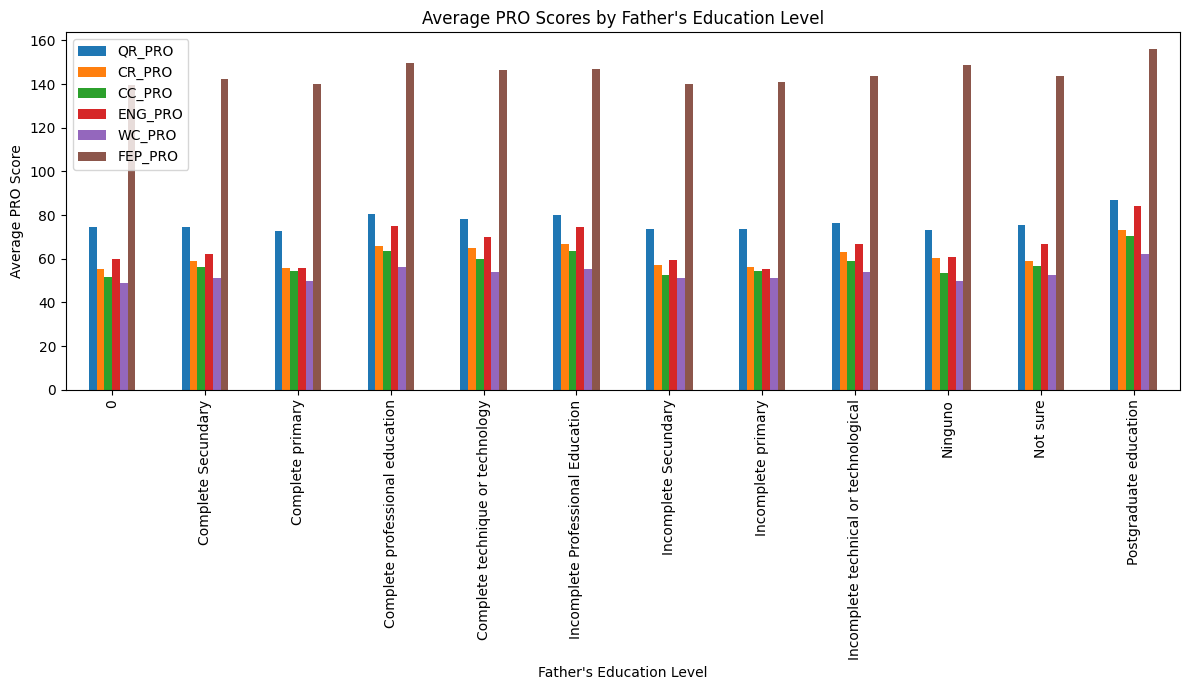

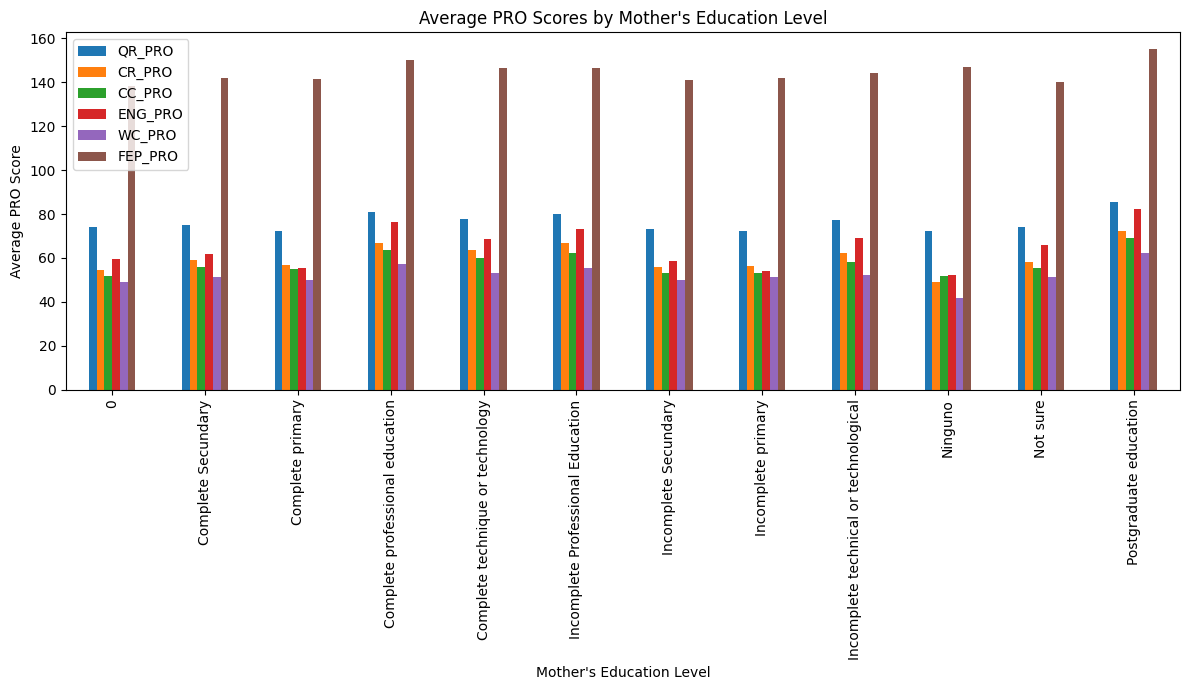

In [16]:
# Visualize the influence of father's education on PRO scores
father_education_pro_impact.plot(kind='bar', figsize=(12, 7))
plt.title("Average PRO Scores by Father's Education Level")
plt.xlabel("Father's Education Level")
plt.ylabel("Average PRO Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Visualize the influence of mother's education on PRO scores
mother_education_pro_impact.plot(kind='bar', figsize=(12, 7))
plt.title("Average PRO Scores by Mother's Education Level")
plt.xlabel("Mother's Education Level")
plt.ylabel("Average PRO Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Create a composite index for pro scores

### Subtask:
Combine the individual PRO subject scores into a single index.


**Reasoning**:
Combine the individual PRO subject scores into a single index by calculating the mean of the specified columns and add it as a new column to the dataframe.



In [17]:
# Combine the individual PRO subject scores into a single index
df['PRO_index'] = df[PRO_cols].mean(axis=1)

# Display the first few rows of the DataFrame with the new 'PRO_index' column
display(df[PRO_cols + ['PRO_index']].head())

,QR_PRO,CR_PRO,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,PRO_index
0,71,93,71,93,79,181,98.000000
1,97,38,86,98,78,201,99.666667
2,17,1,18,43,22,113,35.666667
3,65,35,76,80,48,137,73.500000
4,94,94,98,100,71,189,107.666667


## Calculate cronbach's alpha for pro scores

### Subtask:
Assess the internal consistency of the PRO subjects.


In [18]:
# Standardize each of the PRO subject columns
Z_pro = df[PRO_cols].apply(lambda x: (x - x.mean())/x.std(ddof=1))

# Calculate Cronbach's alpha for the standardized PRO subject scores
k_pro = Z_pro.shape[1]
item_vars_pro = Z_pro.var(ddof=1, axis=0)
total_var_pro = Z_pro.sum(axis=1).var(ddof=1)
alpha_pro = (k_pro / (k_pro-1)) * (1 - item_vars_pro.sum() / total_var_pro)

# Print Cronbach's alpha for the PRO subjects
print("Cronbach alpha (PRO):", round(alpha_pro, 3))

Cronbach alpha (PRO): 0.773


## Analyze mean pro index by parental education

### Subtask:
Group data by parental education and examine the average PRO index.


**Reasoning**:
Filter rows with missing values in 'PARENT_ED_MAX' or 'PRO_index', then group by 'PARENT_ED_MAX' and calculate the count, mean, and standard deviation of 'PRO_index', and finally display the results.



In [19]:
# Filter out rows where either 'PARENT_ED_MAX' or 'PRO_index' is missing
filtered_df_pro = df.dropna(subset=['PARENT_ED_MAX', 'PRO_index']).copy()

# Group the filtered DataFrame by the 'PARENT_ED_MAX' column and calculate count, mean, and standard deviation
pe_means_pro = filtered_df_pro.groupby('PARENT_ED_MAX')['PRO_index'].agg(n='size', mean='mean', sd='std')

# Display the pe_means_pro DataFrame
display(pe_means_pro)

,n,mean,sd
PARENT_ED_MAX,,,
0,18,65.268519,24.287503
1,327,71.020897,17.732423
2,120,73.012500,20.911245
3,372,71.079749,18.519315
4,526,71.170152,18.976140
5,788,71.676184,18.841959
6,2702,73.025598,19.504619
7,301,76.042082,17.647319
8,1387,76.574982,18.869994


## Calculate the top-bottom gap for pro index

### Subtask:
Determine the difference in average PRO index between the highest and lowest parental education levels.


**Reasoning**:
Calculate the top-bottom gap in the average PRO index based on parental education levels if there are enough education levels to compare.



In [20]:
if pe_means_pro.shape[0] >= 2:
    gap_pro_raw = pe_means_pro.iloc[-1]["mean"] - pe_means_pro.iloc[0]["mean"]
    print("Top–bottom gap on PRO_index (raw units):", round(gap_pro_raw, 2))

    # Calculate the overall standard deviation of the PRO_index
    overall_sd_pro = df['PRO_index'].std()

    # Calculate the standardized gap
    gap_pro_sd = gap_pro_raw / overall_sd_pro
    print("Top–bottom gap on PRO_index (SD units):", round(gap_pro_sd, 2))

else:
    print("Cannot calculate the top-bottom gap as there are fewer than two parental education levels.")

Top–bottom gap on PRO_index (raw units): 22.1
Top–bottom gap on PRO_index (SD units): 1.12


## Perform regression analysis for pro index

### Subtask:
Model the relationship between the PRO index and parental education, controlling for other factors.


In [21]:
# Define the list of needed columns for the regression model
needed_pro = ["PRO_index", "PARENT_ED_MAX", "GENDER", "SISBEN"]

# Create a new DataFrame by dropping rows with missing values in any of the needed columns
mod_df_pro = df.dropna(subset=needed_pro).copy()

# Fit an OLS (Ordinary Least Squares) model with HC3 robust standard errors
m_pro = smf.ols("PRO_index ~ PARENT_ED_MAX + C(GENDER) + C(SISBEN)", data=mod_df_pro).fit(cov_type="HC3")

# Display the summary table (table 1) of the fitted regression model
display(m_pro.summary().tables[1])

# Fit a reduced OLS model with only gender and SISBEN as independent variables, using HC3 robust standard errors.
m_red_pro = smf.ols("PRO_index ~ C(GENDER) + C(SISBEN)", data=mod_df_pro).fit(cov_type="HC3")

# Calculate the partial R-squared for parental education
rss_full_pro = np.sum(m_pro.resid**2)
rss_red_pro = np.sum(m_red_pro.resid**2)
partial_R2_PE_pro = 1 - rss_full_pro / rss_red_pro if rss_red_pro > 0 else np.nan

# Display the calculated partial R-squared for parental education, rounded to 3 decimal places.
display("Partial R² (PE | Gender, SISBEN) for PRO Index:", round(partial_R2_PE_pro, 3))

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,70.9877,4.171,17.021,0.000,62.813,79.162
C(GENDER)[T.M],1.4173,0.344,4.119,0.000,0.743,2.092
C(SISBEN)[T.Esta clasificada en otro Level del SISBEN],-2.4371,4.653,-0.524,0.600,-11.557,6.683
C(SISBEN)[T.It is not classified by the SISBEN],-1.5450,4.207,-0.367,0.713,-9.790,6.700
C(SISBEN)[T.Level 1],-9.9065,4.206,-2.356,0.018,-18.149,-1.664
C(SISBEN)[T.Level 2],-8.3129,4.208,-1.976,0.048,-16.560,-0.066
C(SISBEN)[T.Level 3],-6.5504,4.270,-1.534,0.125,-14.919,1.818
PARENT_ED_MAX,1.2897,0.069,18.659,0.000,1.154,1.425


'Partial R² (PE | Gender, SISBEN) for PRO Index:'

np.float64(0.027)

## Interpretation:

 1. The composite PRO index, created by averaging individual PRO subject scores, exhibits good internal consistency with a Cronbach's alpha of approximately 0.773.

 2. There is a clear positive trend between parental education level and the mean PRO index; higher parental education levels are associated with higher average PRO scores.

 3. A substantial difference of 1.12 SD units exists in the average PRO index between students with the highest and lowest parental education levels.

 4. Parental education uniquely explains approximately 2.7% of the variance in the PRO index scores, even after controlling for gender and SISBEN, indicating a meaningful, independent influence.

## Summarize and explain the findings

### Subtask:
Present the results of the analysis and interpret their meaning.


In [22]:
print("--- S11 Analysis ---")
print("Cronbach alpha (S11):", round(alpha, 3))
print("\nMean S11 index by parental education (ordered):")
display(pe_means)
print("\nTop–bottom gap on S11_index (SD units):", round(gap_sd, 2))
print("95% CI for gap:", [round(ci[0],2), round(ci[1],2)])
print("\nPartial R² (PE | Gender, SISBEN):", round(partial_R2_PE, 3))

print("\n--- PRO Analysis ---")
print("Cronbach alpha (PRO):", round(alpha_pro, 3))
print("\nMean PRO index by parental education (ordered):")
display(pe_means_pro)
print("\nTop–bottom gap on PRO_index:", round(gap_pro_sd, 2))

# Bootstrap 95% CI for the top–bottom gap for PRO index
rng = np.random.default_rng(42)
sub_pro = df.dropna(subset=["PARENT_ED_MAX","PRO_index"]).copy()
lo_lvl_pro, hi_lvl_pro = sub_pro["PARENT_ED_MAX"].min(), sub_pro["PARENT_ED_MAX"].max()
a_pro = sub_pro.loc[sub_pro["PARENT_ED_MAX"]==hi_lvl_pro, "PRO_index"].to_numpy()
b_pro = sub_pro.loc[sub_pro["PARENT_ED_MAX"]==lo_lvl_pro, "PRO_index"].to_numpy()
B=3000
gaps_pro = rng.choice(a_pro, (B, a_pro.size), True).mean(axis=1) - rng.choice(b_pro, (B, b_pro.size), True).mean(axis=1)
ci_pro_raw = np.percentile(gaps_pro, [2.5,97.5])
print("95% CI for gap (raw units):", [round(ci_pro_raw[0],2), round(ci_pro_raw[1],2)])

# Calculate the overall standard deviation of the PRO_index
overall_sd_pro = df['PRO_index'].std()

# Calculate the standardized 95% CI
ci_pro_sd = [ci_pro_raw[0] / overall_sd_pro, ci_pro_raw[1] / overall_sd_pro]
print("95% CI for gap (SD units):", [round(ci_pro_sd[0],2), round(ci_pro_sd[1],2)])


print("\nPartial R² (PE | Gender, SISBEN) for PRO Index:", round(partial_R2_PE_pro, 3))

--- S11 Analysis ---
Cronbach alpha (S11): 0.896

Mean S11 index by parental education (ordered):


,n,mean,sd
PARENT_ED_MAX,,,
0,18,-0.372294,0.948715
1,327,-0.410394,0.688786
2,120,-0.187051,0.881058
3,372,-0.317044,0.771814
4,526,-0.356119,0.746606
5,788,-0.311752,0.745742
6,2702,-0.230432,0.767804
7,301,-0.071271,0.753967
8,1387,-0.065319,0.792347



Top–bottom gap on S11_index (SD units): 0.9
95% CI for gap: [np.float64(0.47), np.float64(1.32)]

Partial R² (PE | Gender, SISBEN): 0.044

--- PRO Analysis ---
Cronbach alpha (PRO): 0.773

Mean PRO index by parental education (ordered):


,n,mean,sd
PARENT_ED_MAX,,,
0,18,65.268519,24.287503
1,327,71.020897,17.732423
2,120,73.012500,20.911245
3,372,71.079749,18.519315
4,526,71.170152,18.976140
5,788,71.676184,18.841959
6,2702,73.025598,19.504619
7,301,76.042082,17.647319
8,1387,76.574982,18.869994



Top–bottom gap on PRO_index: 1.12
95% CI for gap (raw units): [np.float64(11.04), np.float64(32.64)]
95% CI for gap (SD units): [np.float64(0.56), np.float64(1.65)]

Partial R² (PE | Gender, SISBEN) for PRO Index: 0.027


# Unified Analysis Summary

This analysis consolidates the findings regarding the influence of parental education on both S11 and PRO assessment scores.

## Key Metrics Summary:

As shown in the output above, for both S11 and PRO scores:

*   **Cronbach's Alpha** indicates good internal consistency for both composite indices.
*   **Mean Index by Parental Education** shows a general increasing trend in average scores as parental education level rises.
*   **Top-Bottom Gap** highlights the performance difference between students with the highest and lowest levels of parental education.
*   **Partial R²** quantifies the unique contribution of parental education in explaining the variance of the scores, after accounting for gender and SISBEN.

## Interpretation:

The unified results confirm that parental education is positively associated with academic performance on both the S11 and PRO assessments. Students from backgrounds with higher parental education levels tend to achieve higher scores on both sets of tests. The analysis of the top-bottom gap and partial R² for both indices further supports that parental education has a meaningful influence on student outcomes, even when considering other demographic factors.

This consistent finding across both S11 and PRO assessments underscores the broader impact of socioeconomic factors, as partly captured by parental education.

## Analyze Performance by Stratum

### Subtask:
Investigate the relationship between socioeconomic stratum and academic outcomes by grouping data by stratum and examining average Global Scores, S11 Index, and PRO Index.

In [23]:
# Analyze the performance by STRATUM
stratum_performance = df.groupby('STRATUM').agg(
    Average_Global_Score=('G_SC', 'mean'),
    Average_S11_Index=('S11_index', 'mean'),
    Average_PRO_Index=('PRO_index', 'mean')
).sort_values(by='Average_Global_Score', ascending=False)
print("Performance by Stratum:")
display(stratum_performance)

# Analyze the performance by SISBEN
sisben_performance = df.groupby('SISBEN').agg(
    Average_Global_Score=('G_SC', 'mean'),
    Average_S11_Index=('S11_index', 'mean'),
    Average_PRO_Index=('PRO_index', 'mean')
).sort_values(by='Average_Global_Score', ascending=False)
print("\nPerformance by SISBEN:")
display(sisben_performance)

Performance by Stratum:


,Average_Global_Score,Average_S11_Index,Average_PRO_Index
STRATUM,,,
Stratum 6,181.511166,0.840639,92.234491
Stratum 5,177.387046,0.647797,89.793049
Stratum 4,172.002535,0.382237,85.531580
Stratum 3,163.815328,0.034273,78.035970
Stratum 2,158.199305,-0.197682,73.995119
0,154.000000,-0.641238,69.464286
Stratum 1,152.352838,-0.400935,69.699434



Performance by SISBEN:


,Average_Global_Score,Average_S11_Index,Average_PRO_Index
SISBEN,,,
It is not classified by the SISBEN,167.469074,0.194802,81.333732
Esta clasificada en otro Level del SISBEN,166.052083,-0.010361,80.088542
Level 3,160.991424,-0.102284,75.343339
0,158.619048,-0.423552,73.087302
Level 2,155.893396,-0.287180,72.189230
Level 1,152.680603,-0.383713,69.951872


## Interpretation:
For Stratum, higher stratums (Stratum 6 and 5) consistently show higher average scores across all three metrics (Global Score, S11 Index, and PRO Index). This reinforces that students from higher socioeconomic stratums tend to perform better academically.

For SISBEN, the 'It is not classified by the SISBEN' group performs best on average across all three metrics, followed by 'Esta clasificada en otro Level del SISBEN'. Students in Levels 1, 2, and 3 show progressively lower average scores.

## Gender Performance in Global Assessment

### Subtask:
Compare the average global assessment scores between male and female students.

Average Global Score by Gender:


,G_SC
GENDER,
F,161.278207
M,163.690825


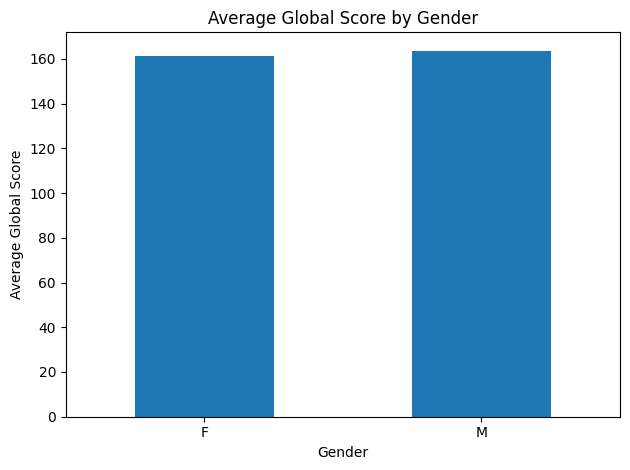

In [24]:
# Analyze the average global score by gender
gender_global_performance = df.groupby('GENDER')['G_SC'].mean()
print("Average Global Score by Gender:")
display(gender_global_performance)

# Optional: Visualize the gender performance
gender_global_performance.plot(kind='bar')
plt.title("Average Global Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Global Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation:
1. the average global score for male students (approximately 163.69) is slightly higher than the average global score for female students (approximately 161.28).

2. This indicates a small but notable difference in performance on the global assessment, with male students performing slightly better on average in this dataset.

# Task
Analyze whether gender gaps change across parental education and strata.

## Analyze gender gap across parental education

### Subtask:
Group data by parental education and gender, then compare the average global scores or S11/PRO indices between genders within each parental education level. Visualize the results.


**Reasoning**:
Group the DataFrame by parental education and gender to calculate the mean global scores, S11 index, and PRO index for each group. Then, unstack the results for visualization.



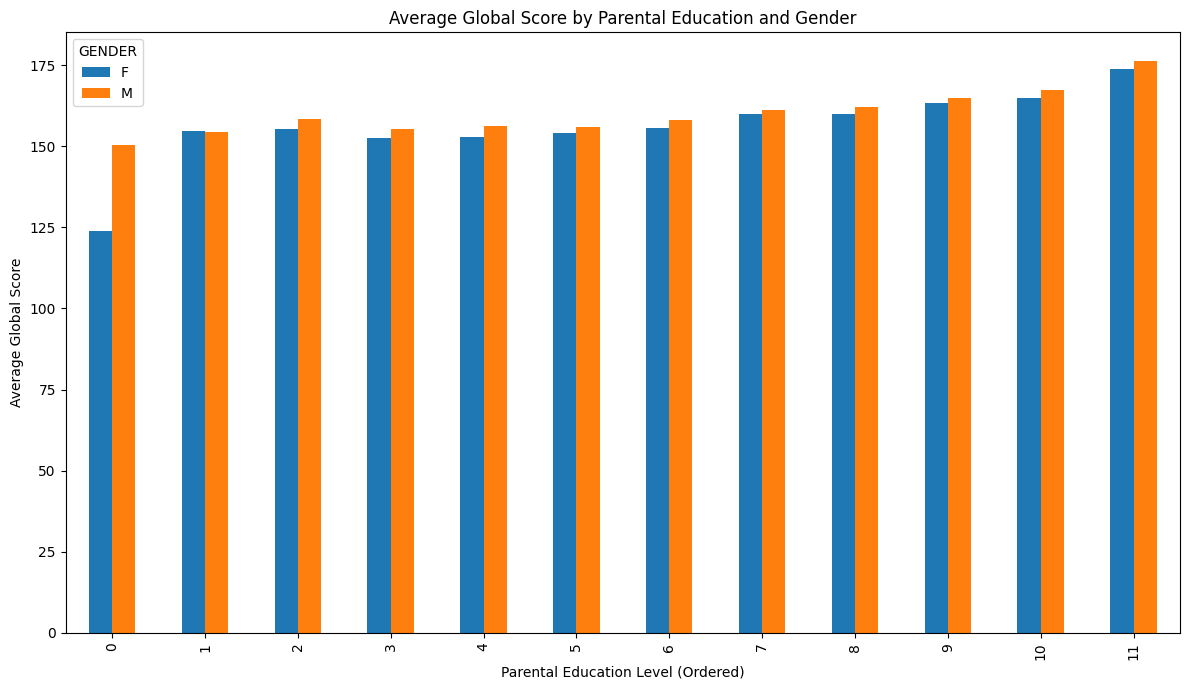

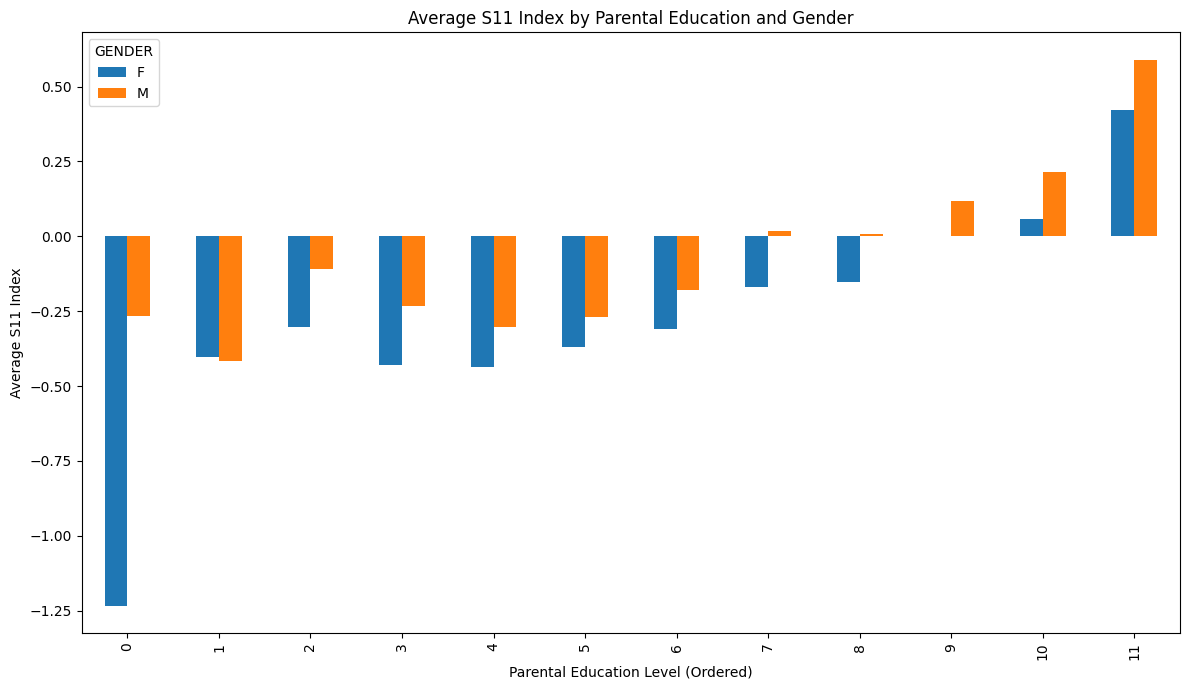

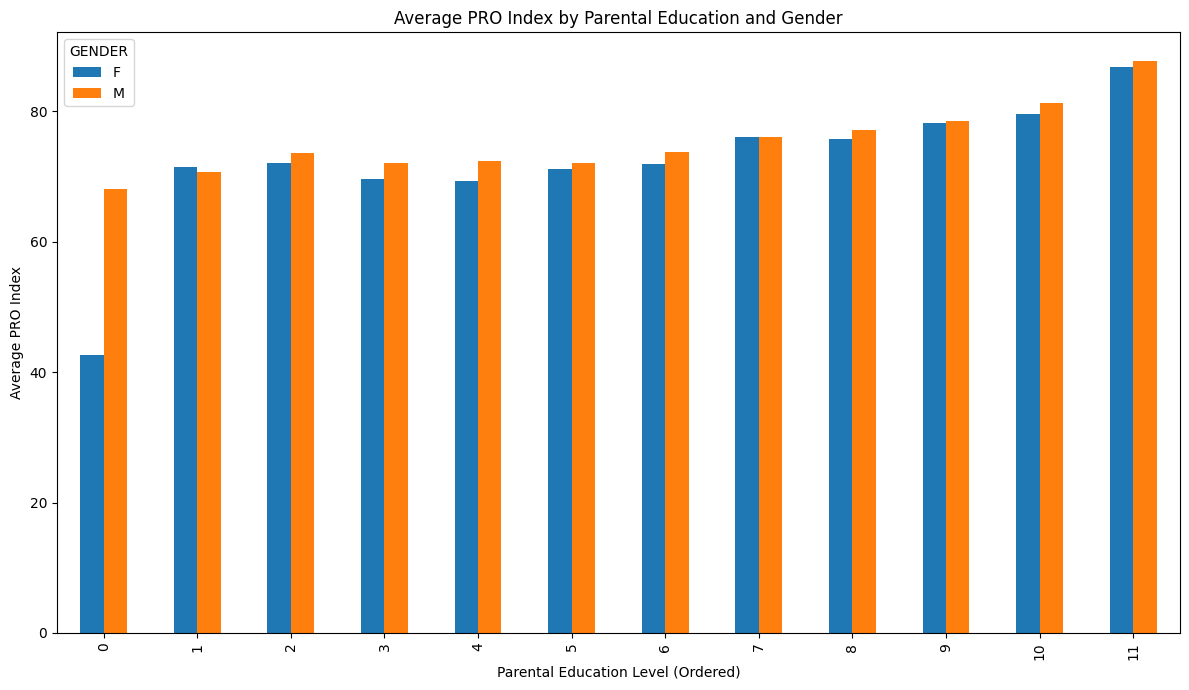

In [25]:
# Group by parental education and gender and calculate the mean global scores
gender_parent_education_global = df.groupby(['PARENT_ED_MAX', 'GENDER'])['G_SC'].mean()

# Group by parental education and gender and calculate the mean S11 index
gender_parent_education_s11 = df.groupby(['PARENT_ED_MAX', 'GENDER'])['S11_index'].mean()

# Group by parental education and gender and calculate the mean PRO index
gender_parent_education_pro = df.groupby(['PARENT_ED_MAX', 'GENDER'])['PRO_index'].mean()

# Unstack and plot global scores by parental education and gender
gender_parent_education_global.unstack().plot(kind='bar', figsize=(12, 7))
plt.title("Average Global Score by Parental Education and Gender")
plt.xlabel("Parental Education Level (Ordered)")
plt.ylabel("Average Global Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Unstack and plot S11 index by parental education and gender
gender_parent_education_s11.unstack().plot(kind='bar', figsize=(12, 7))
plt.title("Average S11 Index by Parental Education and Gender")
plt.xlabel("Parental Education Level (Ordered)")
plt.ylabel("Average S11 Index")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Unstack and plot PRO index by parental education and gender
gender_parent_education_pro.unstack().plot(kind='bar', figsize=(12, 7))
plt.title("Average PRO Index by Parental Education and Gender")
plt.xlabel("Parental Education Level (Ordered)")
plt.ylabel("Average PRO Index")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Analyze gender gap across stratum

### Subtask:
Group data by stratum and gender, then compare the average global scores or S11/PRO indices between genders within each stratum. Visualize the results.


**Reasoning**:
Group the DataFrame by stratum and gender and calculate the mean of the global score, S11 index, and PRO index for each group, then unstack and plot the results to visualize the gender performance across different stratums and indices.



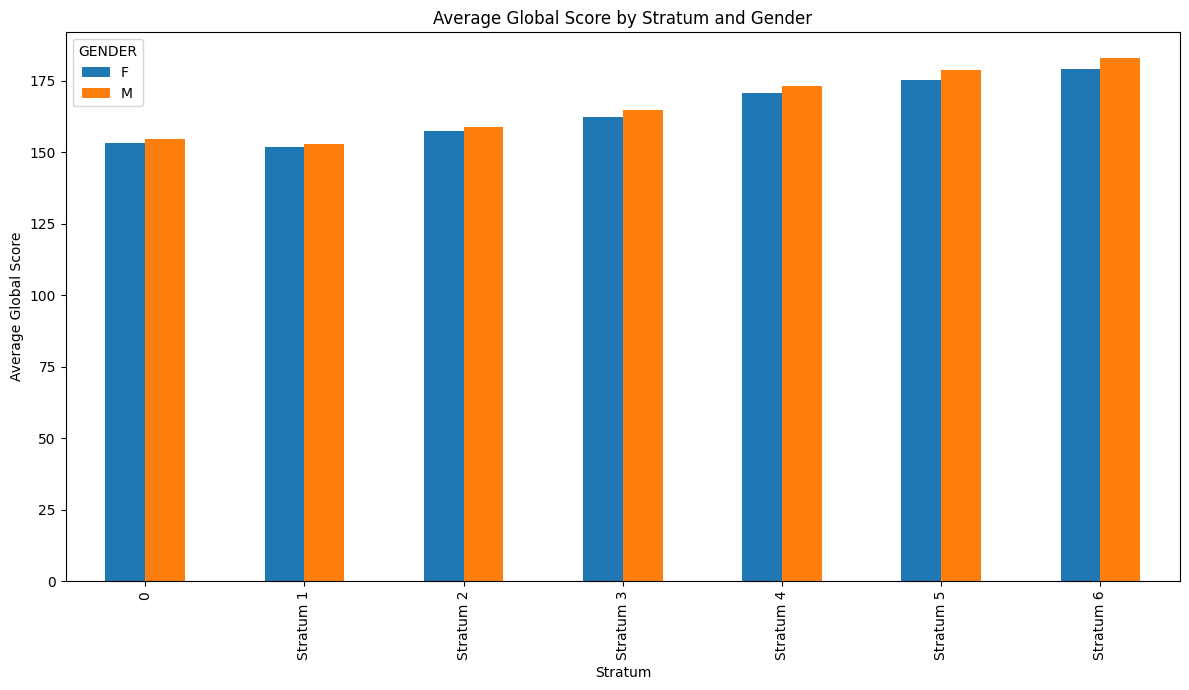

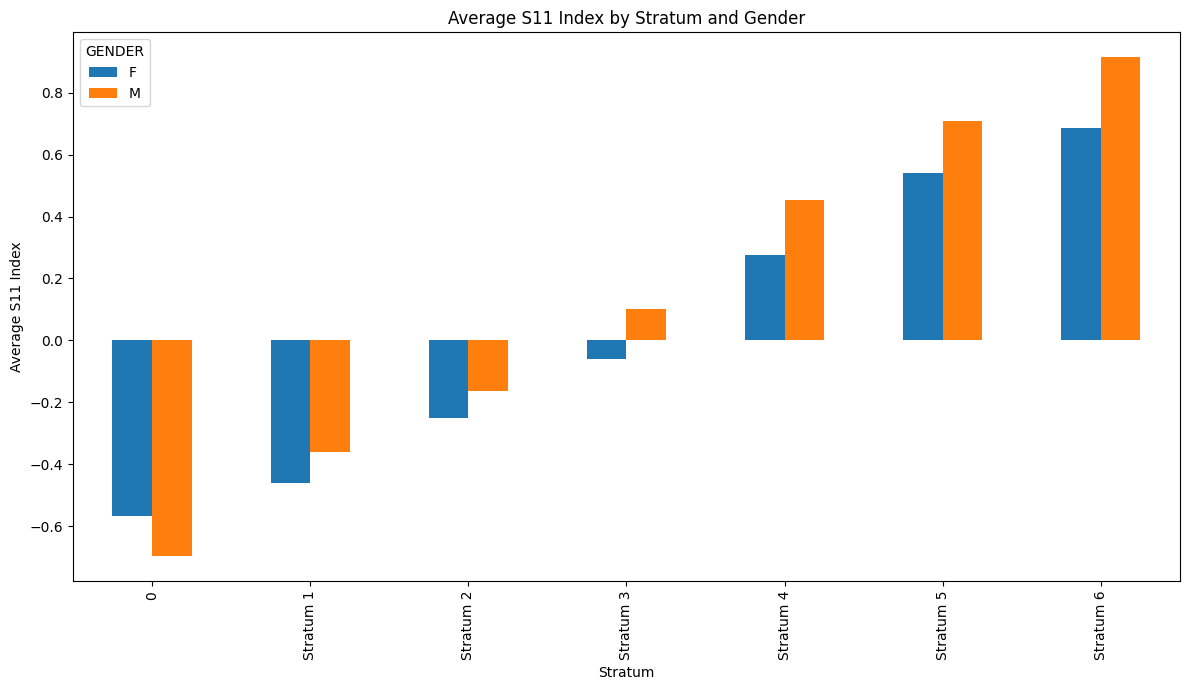

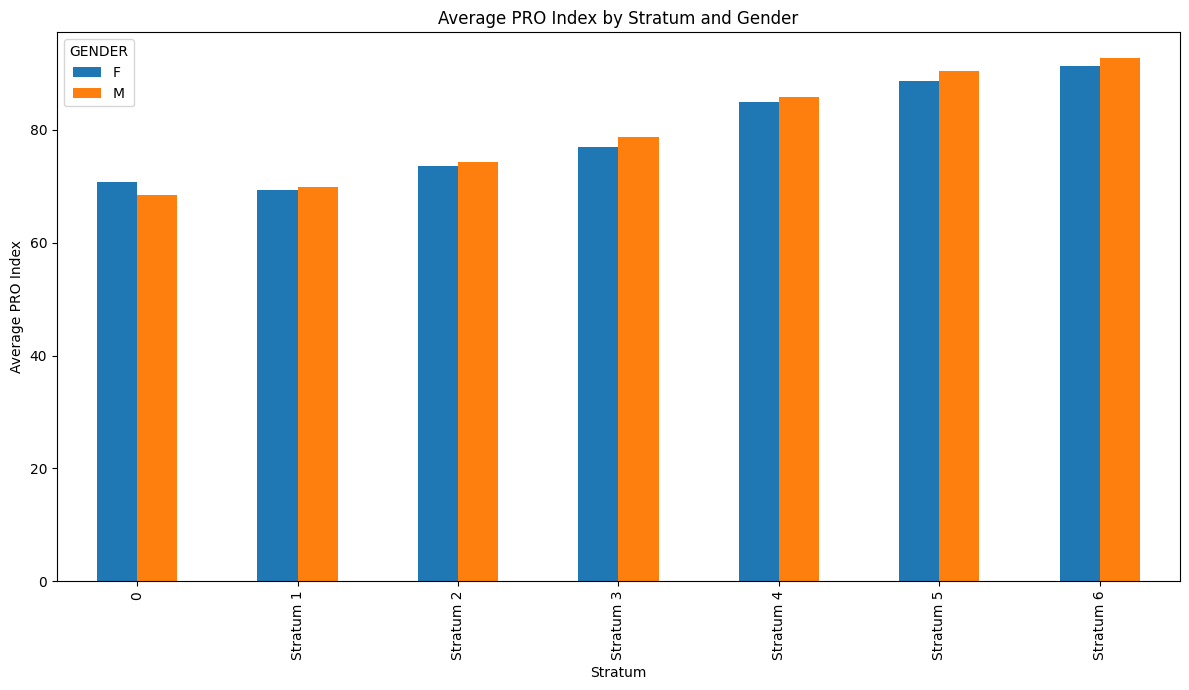

In [26]:
# Group by stratum and gender and calculate the mean global scores
gender_stratum_global = df.groupby(['STRATUM', 'GENDER'])['G_SC'].mean()

# Group by stratum and gender and calculate the mean S11 index
gender_stratum_s11 = df.groupby(['STRATUM', 'GENDER'])['S11_index'].mean()

# Group by stratum and gender and calculate the mean PRO index
gender_stratum_pro = df.groupby(['STRATUM', 'GENDER'])['PRO_index'].mean()

# Unstack and plot global scores by stratum and gender
gender_stratum_global.unstack().plot(kind='bar', figsize=(12, 7))
plt.title("Average Global Score by Stratum and Gender")
plt.xlabel("Stratum")
plt.ylabel("Average Global Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Unstack and plot S11 index by stratum and gender
gender_stratum_s11.unstack().plot(kind='bar', figsize=(12, 7))
plt.title("Average S11 Index by Stratum and Gender")
plt.xlabel("Stratum")
plt.ylabel("Average S11 Index")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Unstack and plot PRO index by stratum and gender
gender_stratum_pro.unstack().plot(kind='bar', figsize=(12, 7))
plt.title("Average PRO Index by Stratum and Gender")
plt.xlabel("Stratum")
plt.ylabel("Average PRO Index")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Perform interaction analysis

### Subtask:
Use regression analysis to formally test for interactions between gender and parental education/stratum on academic performance.


**Reasoning**:
Fit OLS models with interaction terms to formally test for gender differences across parental education and stratum for both S11 and PRO indices, and display the summaries.



In [27]:
import statsmodels.formula.api as smf

# Fit OLS model for S11_index with interaction terms
m_s11_interactions = smf.ols("S11_index ~ PARENT_ED_MAX * C(GENDER) + C(STRATUM) * C(GENDER)", data=df).fit(cov_type="HC3")
print("OLS Model Summary for S11_index with Gender Interactions:")
display(m_s11_interactions.summary().tables[1])

# Fit OLS model for PRO_index with interaction terms
m_pro_interactions = smf.ols("PRO_index ~ PARENT_ED_MAX * C(GENDER) + C(STRATUM) * C(GENDER)", data=df).fit(cov_type="HC3")
print("\nOLS Model Summary for PRO_index with Gender Interactions:")
display(m_pro_interactions.summary().tables[1])

OLS Model Summary for S11_index with Gender Interactions:


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-0.7565,0.262,-2.885,0.004,-1.270,-0.243
C(GENDER)[T.M],0.0064,0.367,0.017,0.986,-0.713,0.726
C(STRATUM)[T.Stratum 1],-0.0591,0.264,-0.224,0.823,-0.576,0.458
C(STRATUM)[T.Stratum 2],0.1031,0.263,0.392,0.695,-0.413,0.619
C(STRATUM)[T.Stratum 3],0.2318,0.263,0.880,0.379,-0.285,0.748
C(STRATUM)[T.Stratum 4],0.5030,0.265,1.898,0.058,-0.016,1.022
C(STRATUM)[T.Stratum 5],0.7608,0.268,2.835,0.005,0.235,1.287
C(STRATUM)[T.Stratum 6],0.8655,0.271,3.197,0.001,0.335,1.396
C(STRATUM)[T.Stratum 1]:C(GENDER)[T.M],0.1247,0.369,0.338,0.736,-0.599,0.849
C(STRATUM)[T.Stratum 2]:C(GENDER)[T.M],0.1138,0.369,0.309,0.758,-0.609,0.836



OLS Model Summary for PRO_index with Gender Interactions:


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,66.9293,3.371,19.852,0.000,60.321,73.537
C(GENDER)[T.M],0.6294,9.929,0.063,0.949,-18.831,20.089
C(STRATUM)[T.Stratum 1],-4.7236,3.442,-1.372,0.170,-11.470,2.023
C(STRATUM)[T.Stratum 2],-1.4822,3.413,-0.434,0.664,-8.172,5.208
C(STRATUM)[T.Stratum 3],0.7299,3.428,0.213,0.831,-5.989,7.449
C(STRATUM)[T.Stratum 4],7.5054,3.492,2.149,0.032,0.661,14.350
C(STRATUM)[T.Stratum 5],10.9372,3.617,3.024,0.002,3.847,18.027
C(STRATUM)[T.Stratum 6],12.8209,3.783,3.389,0.001,5.406,20.236
C(STRATUM)[T.Stratum 1]:C(GENDER)[T.M],1.2367,9.984,0.124,0.901,-18.332,20.805
C(STRATUM)[T.Stratum 2]:C(GENDER)[T.M],1.5092,9.966,0.151,0.880,-18.023,21.041


## Interpretation:

### Data Analysis Key Findings

1. The plots show that while male students tend to have slightly higher average scores overall (Global Score, S11 Index, and PRO Index), this gap appears to vary across different parental education levels. In some lower parental education categories, the gender gap might be smaller or even reversed, while in higher categories, the gap favoring males seems more consistent.
2. Similarly, the plots for stratum and gender show variations in the gender gap across different socioeconomic stratums. The gender gap might be less pronounced in lower stratums and more evident in higher stratums, favoring male students.

